<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Initialization cell
import numpy as np
import matplotlib.pyplot as plt

N = 256
x = np.linspace(0, 2*np.pi, N, endpoint=False)

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

A = 0.1
sigma = 0.2
x1 = np.pi/2
x2 = 3*np.pi/2
theta = np.random.uniform(0, 2*np.pi)

phi1 = gaussian(x1, sigma, A)
phi2 = gaussian(x2, sigma, A)
phi = phi1 + phi2 * np.cos(theta)

history = [phi.copy()]


In [2]:
dt = 0.02
gamma = 0.001
lam = 0.5
delta = 0.05
tau = 0.08

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def clip_guard(phi, max_abs=1.0):
    m = np.max(np.abs(phi))
    return phi * (max_abs / m) if m > max_abs else phi

def evolve(phi):
    collapse = delta * (np.abs(phi) > tau)
    return phi + dt * (laplacian(phi) - gamma * phi + lam * phi**3) - collapse

for t in range(1000):
    phi = evolve(phi)
    phi = clip_guard(phi)
    if t % 50 == 0:
        history.append(phi.copy())


In [3]:
def correlation(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return (np.dot(a, b) / denom) if denom > 0 else 0.0

def collapse_index(phi, eps=1e-3):
    return np.sum(np.abs(phi) < eps) / len(phi)

fidelity = [correlation(h, history[0]) for h in history]
collapse = [collapse_index(h) for h in history]


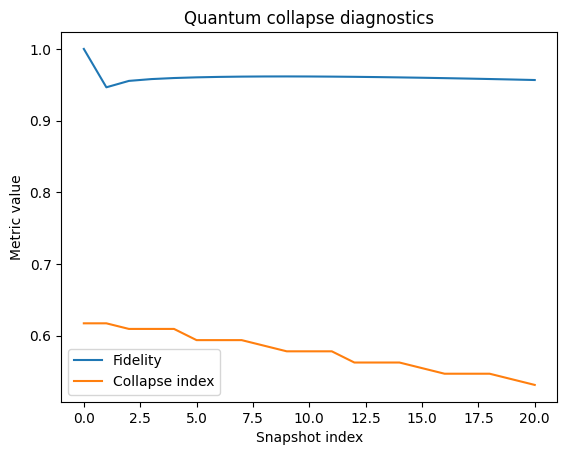

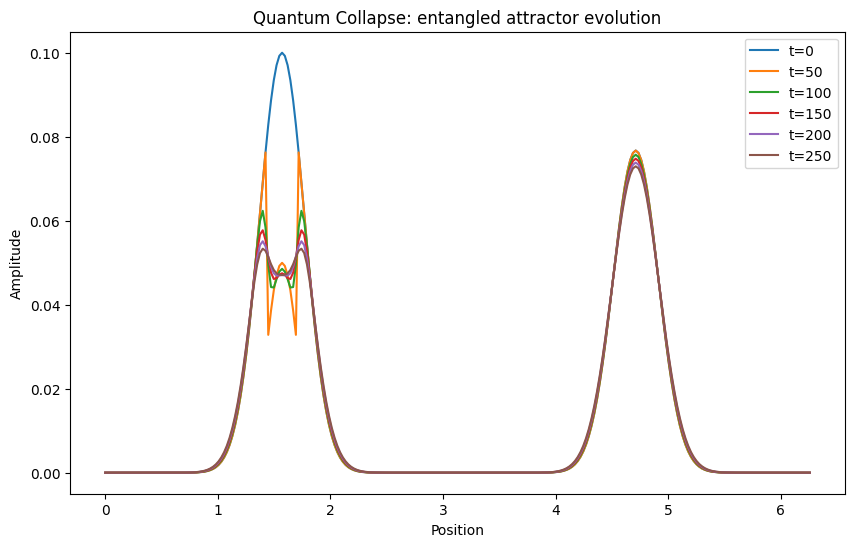

In [4]:
# Fidelity and collapse
plt.plot(fidelity, label="Fidelity")
plt.plot(collapse, label="Collapse index")
plt.xlabel("Snapshot index")
plt.ylabel("Metric value")
plt.title("Quantum collapse diagnostics")
plt.legend()
plt.show()

# Snapshots
plt.figure(figsize=(10,6))
for i, h in enumerate(history[:6]):
    plt.plot(x, h, label=f"t={i*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Quantum Collapse: entangled attractor evolution")
plt.legend()
plt.show()
